In [1]:
import sys
import os
# 将当前目录的上一级加入路径
sys.path.append(os.path.abspath(".."))

import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
import os
import scipy.sparse as sparse
import anndata

import seaborn as sns
from utils import refine, record_memory_usage
import time

sc.logging.print_header()
# sc.logging.print_versions()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3 # errors (0), warnings (1), info (2), hints (3)

sns.set_style("white")

np.random.seed(0)

scanpy==1.10.3 anndata==0.10.9 umap==0.5.11 numpy==1.26.4 scipy==1.13.1 pandas==2.3.3 scikit-learn==1.6.1 statsmodels==0.14.6 igraph==1.0.0 leidenalg==0.11.0 pynndescent==0.6.0


In [12]:
# 读取数据
section_id = '151675'
adata = sc.read_visium(path='../Data/' + section_id, count_file=section_id + '_filtered_feature_bc_matrix.h5')
adata.var_names_make_unique()

reading ..\Data\151675\151675_filtered_feature_bc_matrix.h5
 (0:00:00)


In [14]:
# 数据预处理
# 过滤掉在少于10个细胞中表达的基因，去除低表达基因以减少噪声
sc.pp.filter_genes(adata, min_cells=10)

# 使用seurat_v3方法识别3000个高变基因（Highly Variable Genes），这些基因在细胞间表达差异较大
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=3000)

# 提取高变基因的布尔索引，用于后续筛选
hvg_filter = adata.var['highly_variable']

# 归一化基因表达数据，使每个细胞的总表达量相同（默认归一化到10000），便于细胞间比较
sc.pp.normalize_total(adata, inplace=True)

# log转换
sc.pp.log1p(adata)

# 备份包含所有基因的完整数据集
adata_all_genes = adata.copy()

# 仅保留高变基因，降维提高计算效率，减少噪声影响
adata = adata[:, hvg_filter]

# 显示过滤后的AnnData对象信息
display(adata)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)


View of AnnData object with n_obs × n_vars = 3592 × 3000
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'

In [ ]:
# 提取表达矩阵和空间坐标，保存到CSV文件 (略)

# 1. 获取表达矩阵（转为DataFrame格式）
expression_df = adata.to_df()

# 2. 获取空间坐标
spatial_coords_df = pd.DataFrame(
    adata.obsm['spatial'], 
    index=adata.obs.index,
    columns=['spatial_x', 'spatial_y']
)

# 3. 合并空间坐标和表达矩阵，确保对应关系
combined_df = pd.concat([spatial_coords_df, expression_df], axis=1)

# 4. 保存到CSV文件（与当前notebook同一目录）
output_file = f'{section_id}_expression_with_spatial_logtransform.csv'
combined_df.to_csv(output_file, index=True)

print(f"数据已保存到: {output_file}")
print(f"数据维度: {combined_df.shape}")
print(f"包含 {len(spatial_coords_df.columns)} 个空间坐标列和 {len(expression_df.columns)} 个基因表达列")
print("\n前5行数据预览:")
display(combined_df.head())

数据已保存到: 151675_expression_with_spatial_logtransform.csv
数据维度: (3592, 3002)
包含 2 个空间坐标列和 3000 个基因表达列

前5行数据预览:


,spatial_x,spatial_y,HES4,TNFRSF4,SCNN1D,VWA1,ATAD3C,AL645728.1,AL109917.1,CFAP74,...,RSPH1,SLC37A1,PKNOX1,GATD3A,ICOSLG,UBE2G2,AP001505.1,POFUT2,S100B,AC007325.2
AAACAACGAATAGTTC-1,3834,2566,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
AAACAAGTATCTCCCA-1,9711,8599,0.322217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
AAACACCAATAACTGC-1,3989,9635,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.443539,0.0
AAACAGAGCGACTCCT-1,9192,4282,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.439566,0.0,0.0,0.743872,0.0
AAACAGGGTCTATATT-1,3586,8195,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


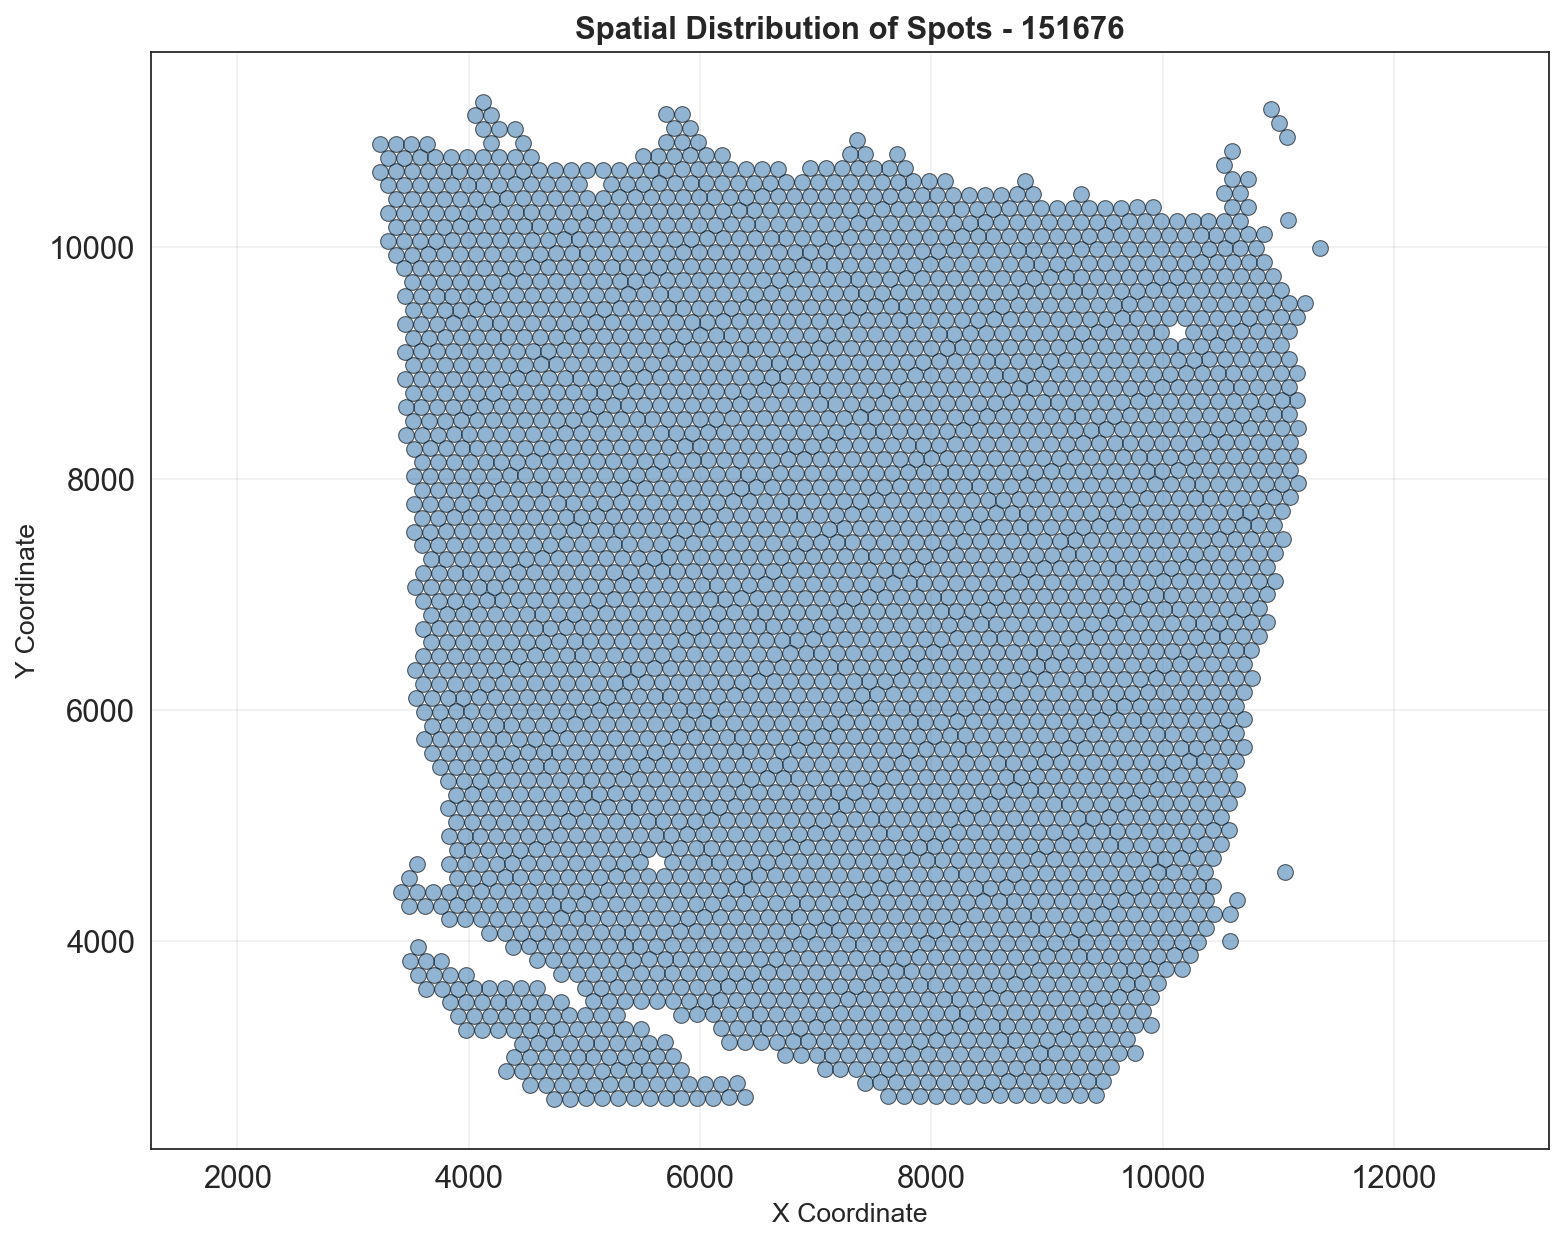

总共有 3460 个spots


In [ ]:
# 根据空间坐标绘制XY轴散点图 (略)
import matplotlib.pyplot as plt

# 获取空间坐标
spatial_coords = adata.obsm['spatial']
x_coords = spatial_coords[:, 0]
y_coords = spatial_coords[:, 1]

# 绘制散点图
plt.figure(figsize=(10, 8))
plt.scatter(x_coords, y_coords, c='steelblue', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)
plt.title(f'Spatial Distribution of Spots - {section_id}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axis('equal')  # 保持X和Y轴比例一致
plt.tight_layout()
plt.show()

print(f"总共有 {len(x_coords)} 个spots")


Median distance to closest cell = 138.00362314084367

Edge weights (distance between cells): median = 138.00362314084367, mode = 137.00364958642524


Edge weights (weights between cells): median = 0.16670164151558636, mode = 0.16612198117491883



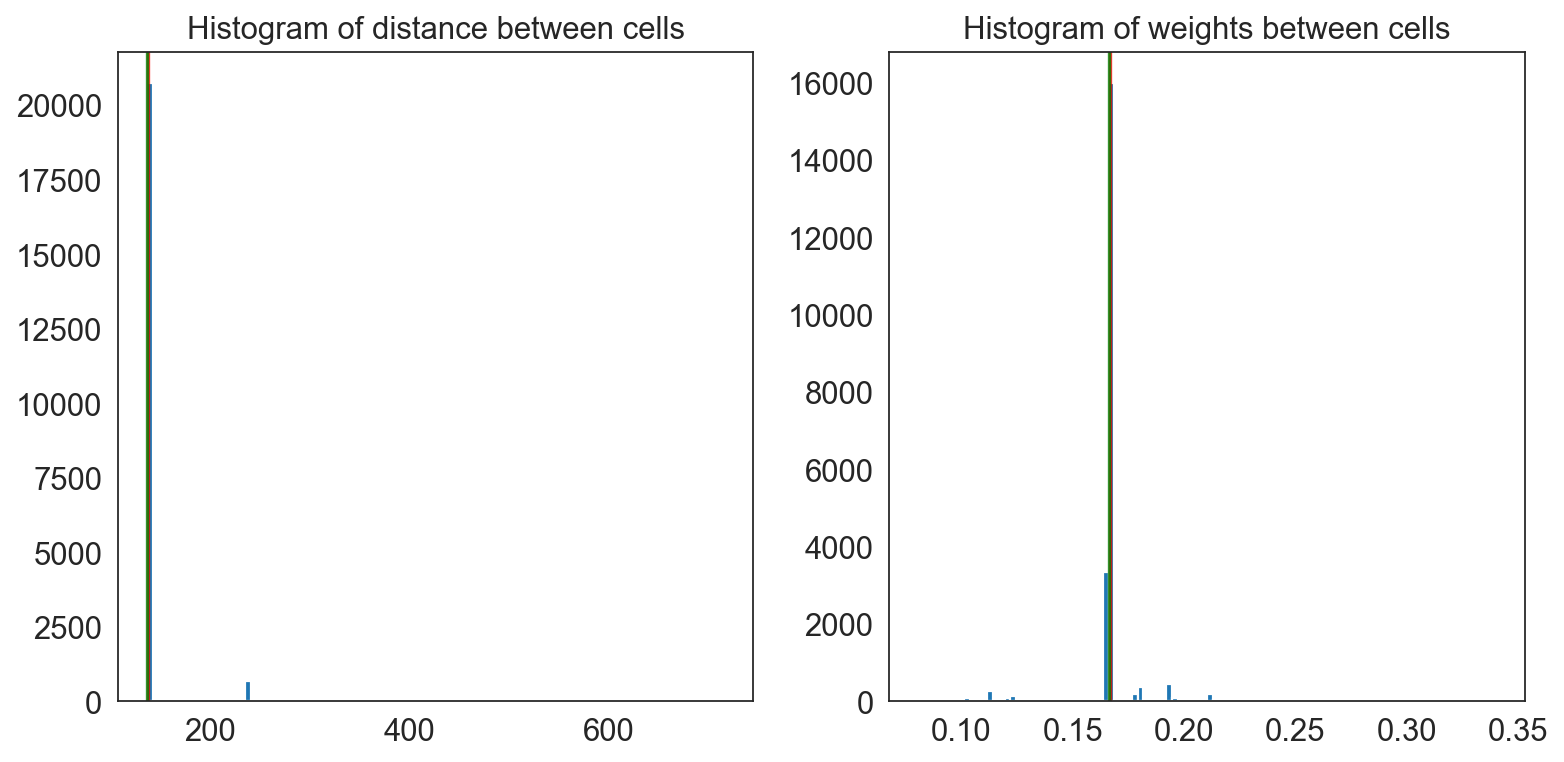

In [23]:
# 构建细胞空间网络
from sklearn.neighbors import NearestNeighbors
from utils import plot_edge_histogram, generate_spatial_weights_fixed_nbrs

num_neighbours = 6
nbrs = NearestNeighbors(algorithm='ball_tree').fit(adata.obsm['spatial'])
distances, indices = nbrs.kneighbors(n_neighbors=num_neighbours)
median_cell_distance = np.median(distances)
print(f"\nMedian distance to closest cell = {median_cell_distance}")

# 将细胞间距离以直方图的形式给出
weights_graph, distance_graph = generate_spatial_weights_fixed_nbrs(adata.obsm['spatial'], num_neighbours=num_neighbours, decay_type='reciprocal', nbr_object=nbrs, verbose=False)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
plot_edge_histogram(distance_graph, ax[0], title='distance between cells')
plot_edge_histogram(weights_graph, ax[1], title='weights between cells')
fig.tight_layout()

In [24]:
# 数据增强
from utils import weighted_concatenate, zscore, matrix_to_adata

gene_list = adata.var.index

nbrhood_contribution = 0.2

neighbour_agg_matrix = weights_graph @ adata.X

if sparse.issparse(adata.X):
    concatenated = sparse.hstack((adata.X, neighbour_agg_matrix), )
else:
    concatenated = np.concatenate((adata.X, neighbour_agg_matrix), axis=1,)

matrix = weighted_concatenate(zscore(adata.X, axis=0), zscore(neighbour_agg_matrix, axis=0), nbrhood_contribution)


if sparse.issparse(matrix):
    st_dev_pergene = matrix.toarray().std(axis=0)
else:
    st_dev_pergene = matrix.std(axis=0)

enhanced_data = matrix_to_adata(matrix, adata)
display(enhanced_data)

num_nbrs: 3000


AnnData object with n_obs × n_vars = 3592 × 6000
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'is_nbr'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'

In [25]:
# Ground Truth
enhanced_data.obs['Ground Truth'] = pd.read_csv(os.path.join('../Data', section_id, section_id + '_truth.txt'), sep='\t', header=None, index_col=0)

In [26]:
# 对增强数据做PCA，实际使用
start_time = time.time()
sc.pp.pca(enhanced_data, n_comps=100)
low_dim_x = enhanced_data.obsm['X_pca']

# 原始数据，实际未使用
sc.pp.pca(adata, n_comps=50)

computing PCA
    with n_comps=100
    finished (0:00:04)
computing PCA
    with n_comps=50
    finished (0:00:00)


In [ ]:
# 保存原始数据PCA后的结果到CSV文件 (略)

# 1. 获取原始数据的PCA结果（50个主成分）
pca_data = adata.obsm['X_pca']

# 2. 转换为DataFrame，保留样本索引确保与空间坐标对应
pca_columns = [f'PC_{i+1}' for i in range(pca_data.shape[1])]
pca_df = pd.DataFrame(
    pca_data,
    index=adata.obs.index,
    columns=pca_columns
)

# 3. 获取空间坐标并合并（确保数据对应）
spatial_coords_pca = pd.DataFrame(
    adata.obsm['spatial'], 
    index=adata.obs.index,
    columns=['spatial_x', 'spatial_y']
)
pca_combined_df = pd.concat([spatial_coords_pca, pca_df], axis=1)

# 4. 保存到CSV文件
pca_output_file = f'{section_id}_pca_original_logtransform.csv'
pca_combined_df.to_csv(pca_output_file, index=True)

print(f"原始数据PCA结果已保存到: {pca_output_file}")
print(f"数据维度: {pca_combined_df.shape}")
print(f"包含 {len(spatial_coords_pca.columns)} 个空间坐标列和 {len(pca_df.columns)} 个PCA分量列")
print("\n前5行数据预览:")
display(pca_combined_df.head())

原始数据PCA结果已保存到: 151676_pca_original_logtransform.csv
数据维度: (3460, 52)
包含 2 个空间坐标列和 50 个PCA分量列

前5行数据预览:


,spatial_x,spatial_y,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,...,PC_41,PC_42,PC_43,PC_44,PC_45,PC_46,PC_47,PC_48,PC_49,PC_50
AAACAAGTATCTCCCA-1,9650,8666,-1.772127,0.449687,0.061165,0.237428,-0.921886,-1.321663,-0.454995,-0.373809,...,0.268578,-0.605896,-0.035839,0.958432,0.657600,-0.867726,0.007399,-0.433351,0.315282,-0.308546
AAACAATCTACTAGCA-1,5630,3006,-2.471853,-1.028684,-0.343278,0.107971,0.804449,0.277814,0.671514,1.465584,...,-0.590807,-0.331553,0.190563,0.053659,-0.504092,0.856257,-0.771124,-1.148966,-0.474839,0.291366
AAACACCAATAACTGC-1,3928,9702,10.403121,1.687472,-0.535298,0.771619,-1.633401,-1.324518,-0.219969,-0.045219,...,0.212208,0.104077,-1.000276,0.201521,0.217859,0.295778,0.542998,-0.264785,-0.355639,0.385821
AAACAGAGCGACTCCT-1,9131,4350,-2.938804,0.108890,-0.482090,0.411884,-0.368659,0.631487,-1.100147,-0.400539,...,-0.037936,0.080927,-0.591307,0.609774,0.974184,0.111965,0.234592,-0.078792,-0.628399,0.182758
AAACAGGGTCTATATT-1,3525,8261,1.878489,0.095544,1.303807,-0.259599,-0.001267,-0.617629,-1.186303,-0.707707,...,1.070752,0.662959,-0.455376,-1.523066,-0.800010,-0.183070,-0.283751,-1.426428,0.837561,-0.566596


In [27]:
# 计算细胞相似度
from sklearn.metrics.pairwise import cosine_similarity

n_spot = low_dim_x.shape[0]
n_neighbor = 15
init_W = cosine_similarity(low_dim_x)
cos_init = np.zeros((n_spot, n_spot))
for i in range(n_spot):
    vec = init_W[i, :]
    distance = vec.argsort()[:: -1]
    for t in range(n_neighbor + 1):
        y = distance[t]
        cos_init[i, y] = init_W[i, y]

In [28]:
# 基因表达矩阵
from network import sparse_self_representation

C = sparse_self_representation(low_dim_x.T, init_w=cos_init, alpha=1, beta=1)

# 保存矩阵C
output_file = f'{section_id}_matrix_C.csv'
C_df = pd.DataFrame(C, index=enhanced_data.obs.index, columns=enhanced_data.obs.index)
C_df.to_csv(output_file, index=True)
print(f"自表示矩阵C已保存到: {output_file}")

# Epoch 99, loss: 784.230: 100%|██████████| 100/100 [02:59<00:00,  1.80s/it]


自表示矩阵C已保存到: 151675_matrix_C.csv


In [ ]:
# 计算残差矩阵 X - XC (略)
# 形状确认：
# low_dim_x: (3460, 100) - 样本 x 特征
# low_dim_x.T: (100, 3460) - 特征 x 样本（传入sparse_self_representation）
# C: (3460, 3460) - 样本间的自表示系数矩阵

# 在sparse_self_representation中的最小化目标是：||x - x @ C||_F
# 其中x是(100, 3460)，所以：
# x @ C = (100, 3460) @ (3460, 3460) = (100, 3460)
# residual = x - x @ C

X = low_dim_x.T  # (100, 3460)，特征 x 样本，对应sparse_self_representation中的x
X_recon = X @ C  # (100, 3460) @ (3460, 3460) = (100, 3460)
residual = X - X_recon  # (100, 3460)

# 保存残差矩阵到CSV文件
# 行为特征维度，列为样本
residual_output_file = f'{section_id}_residual.csv'
residual_df = pd.DataFrame(
    residual, 
    index=[f'PC_{i+1}' for i in range(residual.shape[0])],
    columns=enhanced_data.obs.index
)
residual_df.to_csv(residual_output_file, index=True)

print(f"残差矩阵已保存到: {residual_output_file}")
print(f"残差矩阵形状: {residual.shape} (特征维度 x 样本数)")
print(f"\n残差矩阵统计信息:")
print(f"  最小值: {residual.min():.6f}")
print(f"  最大值: {residual.max():.6f}")
print(f"  平均值: {residual.mean():.6f}")
print(f"  标准差: {residual.std():.6f}")
print(f"  Frobenius范数: {np.linalg.norm(residual, 'fro'):.6f}")


残差矩阵已保存到: 151675_residual.csv
残差矩阵形状: (100, 3592) (特征维度 x 样本数)

残差矩阵统计信息:
  最小值: -30.464340
  最大值: 19.050193
  平均值: 0.011334
  标准差: 1.339512
  Frobenius范数: 802.842617


X与残差矩阵的皮尔逊相关系数分析

【总体相关系数】
  Pearson相关系数: 0.618469
  P-value: 0.000000e+00

【按特征维度（PCA）的相关系数统计】
  最小值: 0.093408
  最大值: 0.857933
  平均值: 0.750604
  中位数: 0.803512
  标准差: 0.151626

【按样本的相关系数统计】
  最小值: -0.544824
  最大值: 0.974722
  平均值: 0.619206
  中位数: 0.673545
  标准差: 0.237030

按特征的相关系数已保存到: 151675_pearson_correlation_by_features.csv
按样本的相关系数已保存到: 151675_pearson_correlation_by_samples.csv


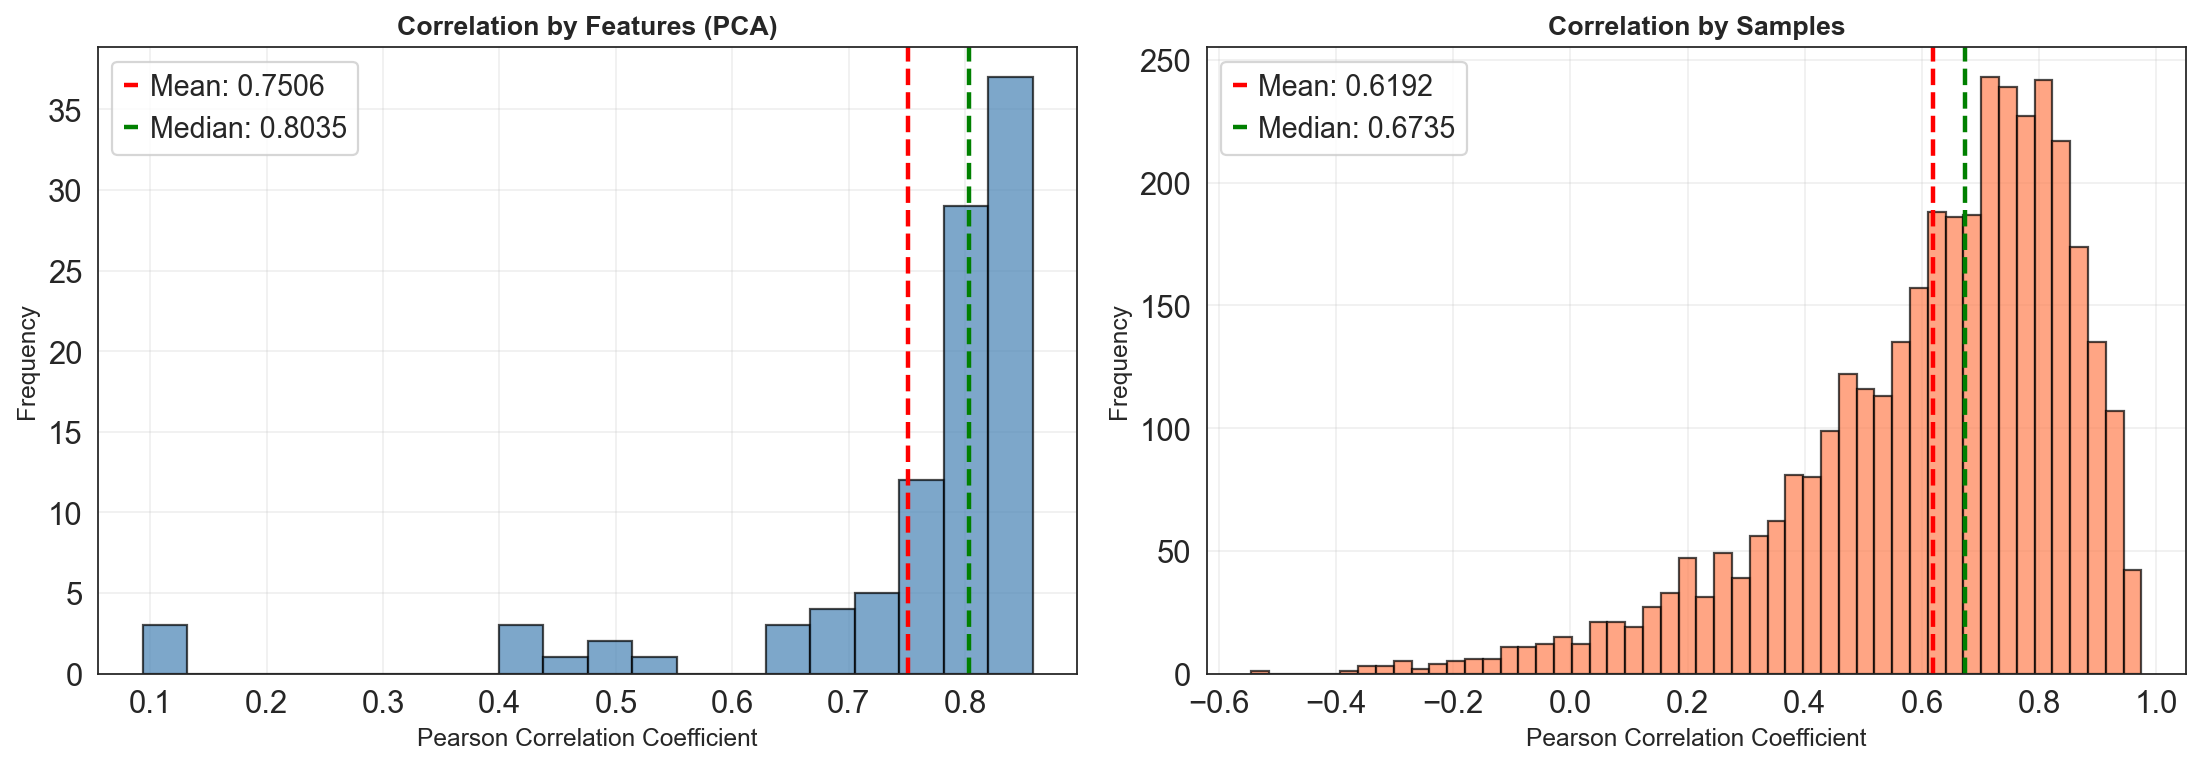

In [30]:
# 计算X和残差矩阵的皮尔逊相关系数
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform

# X: (100, 3460) - 特征 x 样本
# residual: (100, 3460) - 特征 x 样本

# 1. 按特征维度计算相关系数（100个相关系数，每个对应一个PCA特征）
feature_correlations = np.array([
    pearsonr(X[i, :], residual[i, :])[0] for i in range(X.shape[0])
])

# 2. 计算总体相关系数（将所有数据展平后计算）
X_flat = X.flatten()
residual_flat = residual.flatten()
overall_corr, overall_pval = pearsonr(X_flat, residual_flat)

# 3. 按样本计算相关系数（3460个相关系数，每个对应一个样本）
sample_correlations = np.array([
    pearsonr(X[:, i], residual[:, i])[0] for i in range(X.shape[1])
])

# 打印统计信息
print("=" * 70)
print("X与残差矩阵的皮尔逊相关系数分析")
print("=" * 70)

print("\n【总体相关系数】")
print(f"  Pearson相关系数: {overall_corr:.6f}")
print(f"  P-value: {overall_pval:.6e}")

print("\n【按特征维度（PCA）的相关系数统计】")
print(f"  最小值: {feature_correlations.min():.6f}")
print(f"  最大值: {feature_correlations.max():.6f}")
print(f"  平均值: {feature_correlations.mean():.6f}")
print(f"  中位数: {np.median(feature_correlations):.6f}")
print(f"  标准差: {feature_correlations.std():.6f}")

print("\n【按样本的相关系数统计】")
print(f"  最小值: {sample_correlations.min():.6f}")
print(f"  最大值: {sample_correlations.max():.6f}")
print(f"  平均值: {sample_correlations.mean():.6f}")
print(f"  中位数: {np.median(sample_correlations):.6f}")
print(f"  标准差: {sample_correlations.std():.6f}")

# 4. 保存相关系数到CSV文件
# 按特征保存
feature_corr_output = f'{section_id}_pearson_correlation_by_features.csv'
feature_corr_df = pd.DataFrame({
    'Feature': [f'PC_{i+1}' for i in range(len(feature_correlations))],
    'Pearson_Correlation': feature_correlations
})
# feature_corr_df.to_csv(feature_corr_output, index=False)
print(f"\n按特征的相关系数已保存到: {feature_corr_output}")

# 按样本保存
sample_corr_output = f'{section_id}_pearson_correlation_by_samples.csv'
sample_corr_df = pd.DataFrame({
    'Sample': enhanced_data.obs.index,
    'Pearson_Correlation': sample_correlations
})
# sample_corr_df.to_csv(sample_corr_output, index=False)
print(f"按样本的相关系数已保存到: {sample_corr_output}")

# 5. 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 特征相关系数直方图
ax1 = axes[0]
ax1.hist(feature_correlations, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(feature_correlations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {feature_correlations.mean():.4f}')
ax1.axvline(np.median(feature_correlations), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(feature_correlations):.4f}')
ax1.set_xlabel('Pearson Correlation Coefficient', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Correlation by Features (PCA)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 样本相关系数直方图
ax2 = axes[1]
ax2.hist(sample_correlations, bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(sample_correlations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sample_correlations.mean():.4f}')
ax2.axvline(np.median(sample_correlations), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(sample_correlations):.4f}')
ax2.set_xlabel('Pearson Correlation Coefficient', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Correlation by Samples', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)


In [ ]:
# 最终的affinity graph
from MNMST import MNMST_representation

Z, B = MNMST_representation(C, weights_graph)
end_time = time.time()

# 多返回一个矩阵B，可以对矩阵B做K-means聚类

# Epoch 28, loss: 0.120:  29%|██▉       | 29/100 [07:06<17:25, 14.72s/it] 


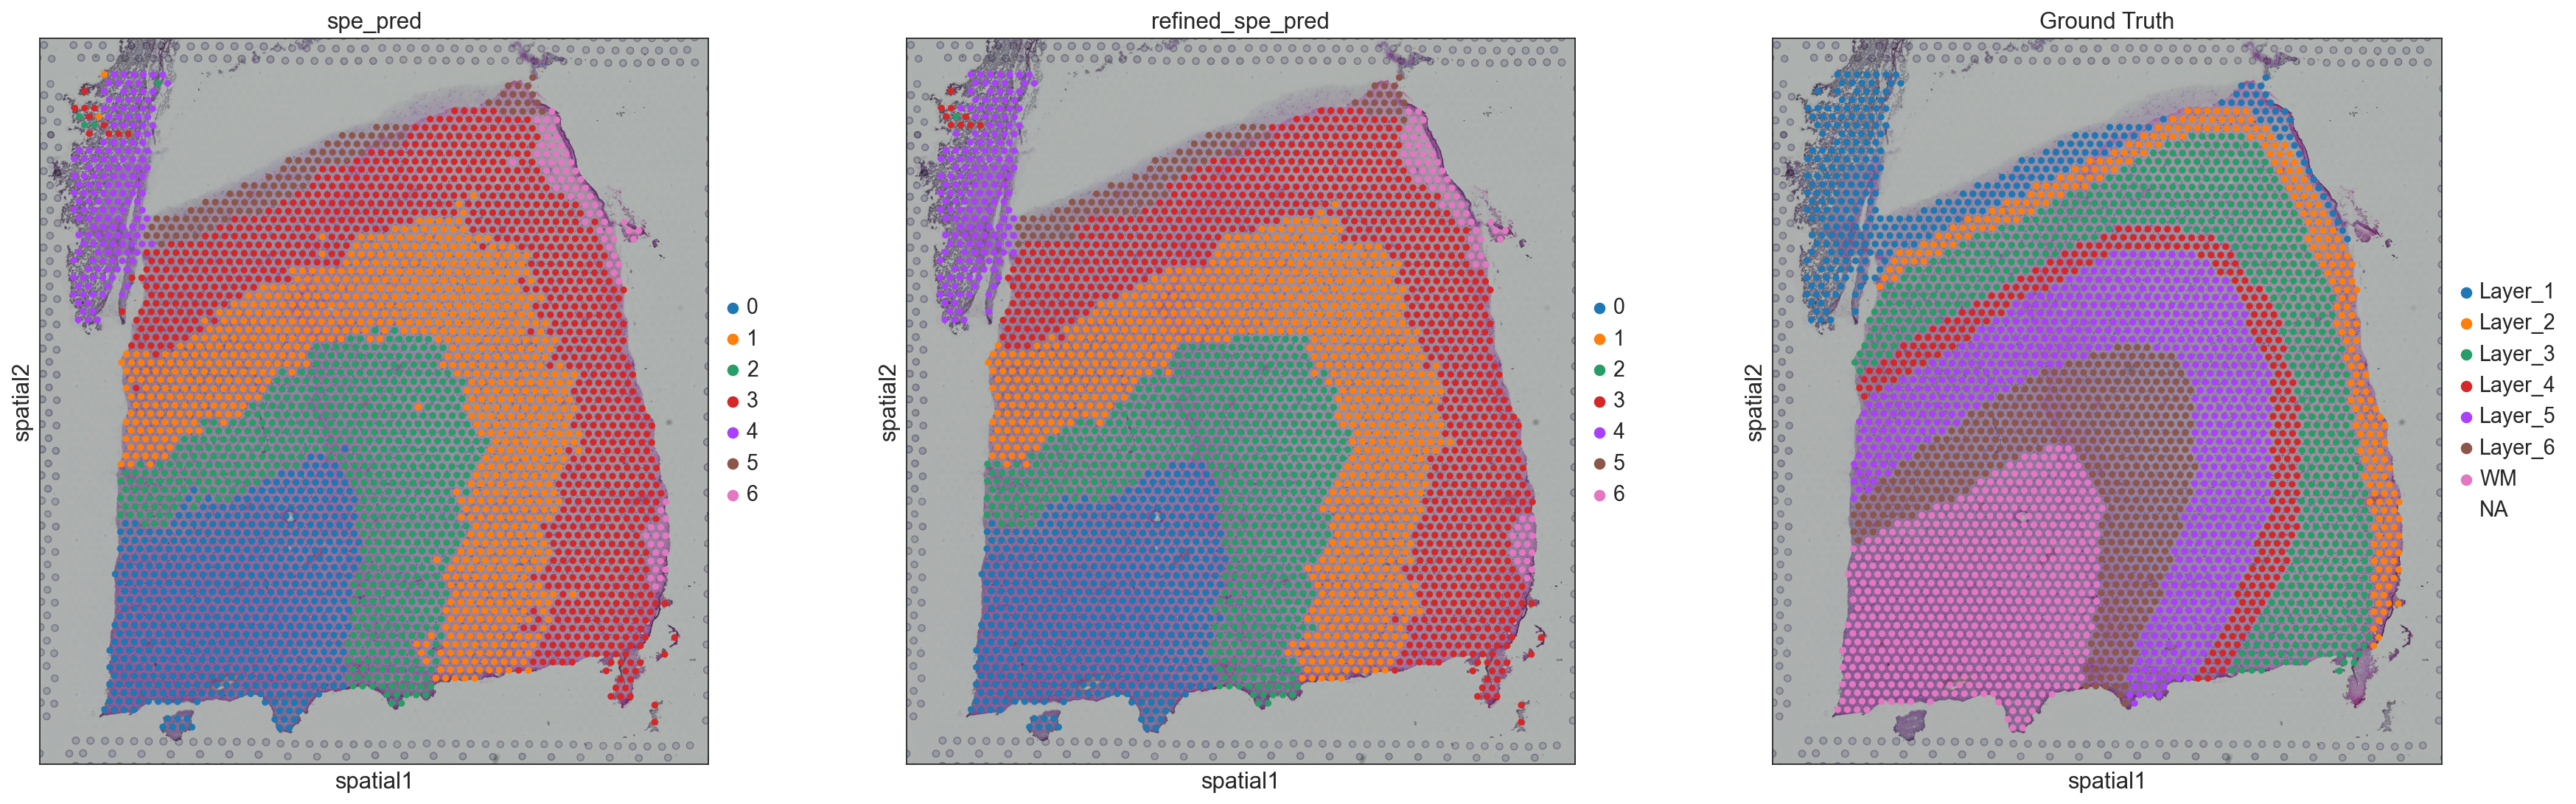

ARI: 0.6201
Refined ARI: 0.6240


In [94]:
# 用谱聚类对MNMST学到的亲和力矩阵进行聚类，作为中间结果验证算法是否学到了有意义的样本相似性结构
from sklearn.cluster import SpectralClustering

n_clusters = 7  # 你可以根据需要设置聚类的数量
spectral = SpectralClustering(n_clusters=n_clusters, affinity='precomputed')
labels = spectral.fit_predict(Z)

enhanced_data.obs['spe_pred'] = labels
enhanced_data.obs["spe_pred"] = enhanced_data.obs["spe_pred"].astype('int')
enhanced_data.obs['spe_pred'] = enhanced_data.obs['spe_pred'].astype('category')
# sc.pl.spatial(enhanced_data, color=['spe_pred', 'Ground Truth'])

# 通过局部邻域投票机制进行优化
refined_pred = refine(sample_id=enhanced_data.obs.index.tolist(), pred=enhanced_data.obs["spe_pred"].tolist(), dis=weights_graph.A, shape="hexagon")
enhanced_data.obs["refined_spe_pred"] = refined_pred
enhanced_data.obs["refined_spe_pred"] = enhanced_data.obs["refined_spe_pred"].astype('category')
sc.pl.spatial(enhanced_data, color=['spe_pred', 'refined_spe_pred', 'Ground Truth'], title=['spe_pred', 'refined_spe_pred', 'Ground Truth'])

ground_truth = enhanced_data.obs['Ground Truth']
valid_mask = ground_truth.notna()
ari = adjusted_rand_score(
    ground_truth[valid_mask], 
    enhanced_data.obs['spe_pred'][valid_mask]
)
refined_ari = adjusted_rand_score(
    ground_truth[valid_mask], 
    enhanced_data.obs['refined_spe_pred'][valid_mask]
)

print(f"ARI: {ari:.4f}")
print(f"Refined ARI: {refined_ari:.4f}")

running Leiden clustering
    finished: found 7 clusters and added
    'MNMST_CPU', the cluster labels (adata.obs, categorical) (0:00:43)


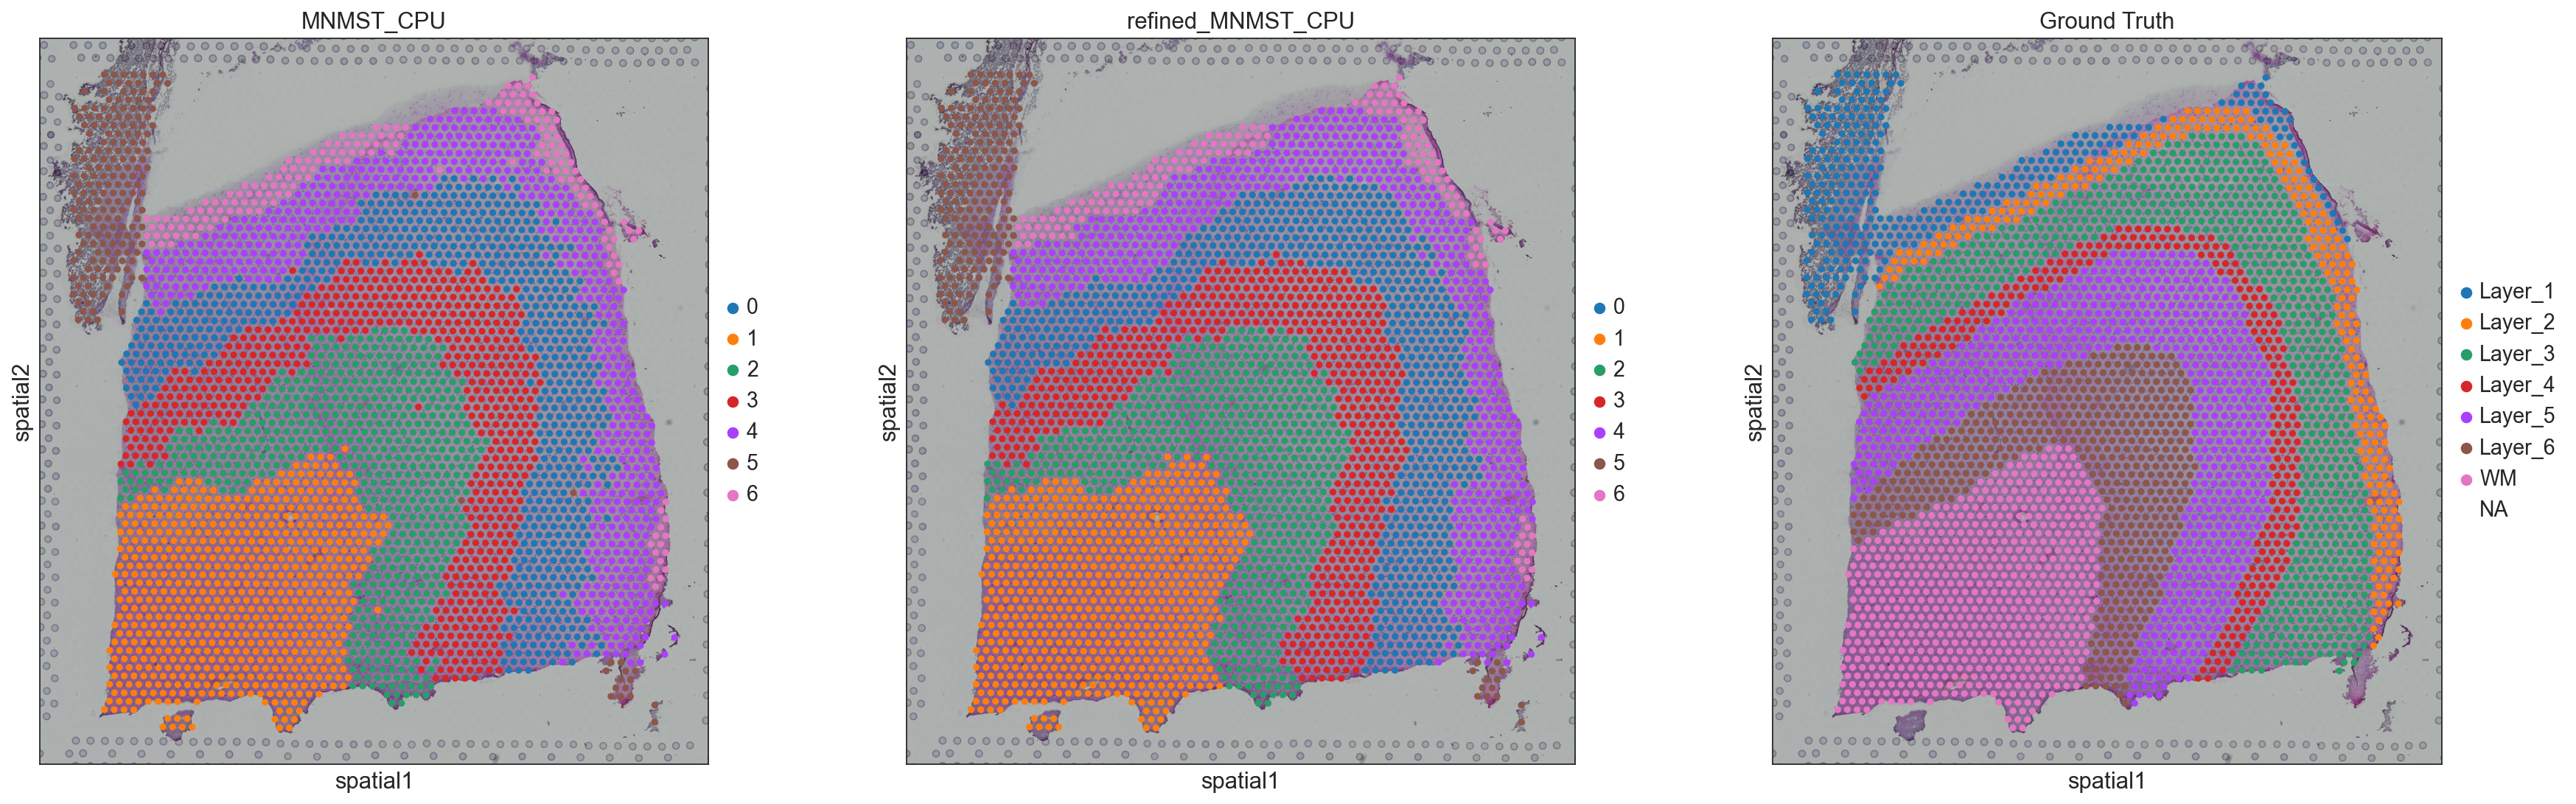

ARI: 0.6047
Refined ARI: 0.6000


In [90]:
# MNMST算法
key_added = 'representation'
conns_key = 'representation'
dists_key = 'representation'

enhanced_data.uns[key_added] = {}
    
representation_dict = enhanced_data.uns[key_added]
    
representation_dict['connectivities_key'] = conns_key
representation_dict['distances_key'] = dists_key
representation_dict['var_names_use'] = enhanced_data.var_names.to_numpy()
    
representation_dict['params'] = {}
representation_dict['params']['method'] = 'umap'
enhanced_data.obsp['representation'] = Z
sc.tl.leiden(enhanced_data, neighbors_key='representation', resolution=1.4, key_added='MNMST_CPU')
# display(enhanced_data.obs['MNMST_CPU'])
# sc.pl.spatial(enhanced_data, color=['MNMST_CPU', 'Ground Truth'])

# 通过局部邻域投票机制进行优化
refined_pred = refine(sample_id=enhanced_data.obs.index.tolist(), pred=enhanced_data.obs["MNMST_CPU"].tolist(), dis=weights_graph.A, shape="hexagon")
enhanced_data.obs["refined_MNMST_CPU"] = refined_pred
enhanced_data.obs["refined_MNMST_CPU"] = enhanced_data.obs["refined_MNMST_CPU"].astype('category')
sc.pl.spatial(enhanced_data, color=['MNMST_CPU', 'refined_MNMST_CPU', 'Ground Truth'], title=['MNMST_CPU', 'refined_MNMST_CPU', 'Ground Truth'])

ground_truth = enhanced_data.obs['Ground Truth']
valid_mask = ground_truth.notna()
ari = adjusted_rand_score(
    ground_truth[valid_mask], 
    enhanced_data.obs['MNMST_CPU'][valid_mask]
)
refined_ari = adjusted_rand_score(
    ground_truth[valid_mask], 
    enhanced_data.obs['refined_MNMST_CPU'][valid_mask]
)

print(f"ARI: {ari:.4f}")
print(f"Refined ARI: {refined_ari:.4f}")